# Olist E-Commerce: Exploratory Data Analysis
**Tool:** Python 3.14 · pandas · matplotlib · seaborn  
**Input:** Data/Cleaned/Olist_Master.csv  
**Output:** Business findings across revenue, regional, category, customer, and operational dimensions  

## Objective
Surface the business story inside 112,650 order-item records spanning
September 2016 – August 2018. Findings from this analysis feed directly
into the SQL KPI layer, dashboard design, and executive recommendation memo.

## 1. Data Loading & Preparation

Loads the validated master table, excludes the October 2018 partial month,
and standardises category labels for consistent display across all outputs.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

# Paths ──────────────────────────────────────────────────────
BASE = r"C:\Users\USER\OneDrive\Documents\Data Portfolio\Operations_Analytics_Portfolio\01_Olist_Analysis"
CLEANED_PATH  = os.path.join(BASE, "Data", "Cleaned")
REPORT_PATH   = os.path.join(BASE, "Reports", "EDA_Findings")

os.makedirs(REPORT_PATH, exist_ok=True)

# Load master table ──────────────────────────────────────────
master = pd.read_csv(
    os.path.join(CLEANED_PATH, "Olist_Master.csv"),
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "shipping_limit_date"
    ]
)

print(f"Loaded: {len(master):,} rows × {master.shape[1]} columns")
print(f"Date range (raw): {master['order_purchase_timestamp'].min().date()} — "
      f"{master['order_purchase_timestamp'].max().date()}")

Loaded: 112,650 rows × 31 columns
Date range (raw): 2016-09-04 — 2018-09-03


In [2]:
# DATE FILTER: Exclude October 2018 ────────────────────────
#
# October 2018 contains 1 order@ a data entry artefact that would
# distort monthly trend analysis and the forecasting baseline.
# Analysis covers September 2016 – August 2018: 24 full months.
# ──────────────────────────────────────────────────────────────

before_rows = len(master)

master = master[master["order_purchase_timestamp"] < "2018-09-01"].copy()

after_rows = len(master)
removed    = before_rows - after_rows

print(f"Rows before filter: {before_rows:,}")
print(f"Rows after filter:  {after_rows:,}")
print(f"Rows excluded:      {removed:,} (Oct 2018 artefact)")
print(f"Date range:   {master['order_purchase_timestamp'].min().date()} — "
      f"{master['order_purchase_timestamp'].max().date()}")

Rows before filter: 112,650
Rows after filter:  112,649
Rows excluded:      1 (Oct 2018 artefact)
Date range:   2016-09-04 — 2018-08-29


In [ ]:
# CATEGORY LABEL STANDARDISATION ────────────────────────────
#
# Source labels use snake_case: bed_bath_table
# Cleaned to Title Case with spaces: Bed Bath Table
# Applied to category_english column.
# "Unknown" category retained as-is.
# ──────────────────────────────────────────────────────────────

master["category_english"] = (
    master["category_english"]
    .str.replace("_", " ", regex=False)
    .str.title()
)

master["order_ym"] = master["order_purchase_timestamp"].dt.to_period("M")

master["order_month"] = master["order_purchase_timestamp"].dt.month_name()

master["order_year"] = master["order_purchase_timestamp"].dt.year

master["total_amount_paid"] = master["price"] + master["freight_value"]

master["delivery_days"] = (
    master["order_delivered_customer_date"] -
    master["order_purchase_timestamp"]
).dt.days

master["delivery_delta"] = (
    master["order_delivered_customer_date"] -
    master["order_estimated_delivery_date"]
).dt.days

print("Derived columns added:")
print("   order_ym               : year-month period label")
print("   order_month            : month name")
print("   order_year             : year integer")
print("   total_amount_paid      : price + freight_value")
print("   delivery_days          : purchase to delivery in days")
print("   delivery_delta         : actual vs estimated delivery (+ = late)")
print(f"\nUnique categories (cleaned): {master['category_english'].nunique()}")
print(f"Sample labels: {sorted(master['category_english'].unique())[:8]}")

Derived columns added:
   order_ym               : year-month period label
   order_month            : month name
   order_year             : year integer
   total_amount_paid      : price + freight_value
   delivery_days          : purchase to delivery in days
   delivery_delta         : actual vs estimated delivery (+ = late)

Unique categories (cleaned): 72
Sample labels: ['Agro Industry And Commerce', 'Air Conditioning', 'Art', 'Arts And Craftmanship', 'Audio', 'Auto', 'Baby', 'Bed Bath Table']


## 2. Revenue Analysis

Quantifies total revenue, monthly growth trajectory, and seasonal
demand patterns across the 24-month analysis window.

In [ ]:
# HEADLINE REVENUE KPIs ──────────────────────────────────────
#
# product_revenue = price only — true GMV, what Olist's sellers earn
# total_amount_paid = price + freight_value, what the customer transacted
# These are kept distinct. Freight is a pass-through logistics cost,
# not earned revenue, and conflating the two overstates business performance.
# ──────────────────────────────────────────────────────────────

master["product_revenue"] = master["price"]

order_level = master.groupby("order_id").agg(
    order_revenue=("product_revenue",   "sum"),
    order_amount_paid=("total_amount_paid", "sum"),
    order_date=("order_purchase_timestamp", "first"),
    state=("state", "first")
).reset_index()

total_revenue        = master["product_revenue"].sum()
total_freight         = master["freight_value"].sum()
total_amount_paid     = master["total_amount_paid"].sum()
total_orders           = master["order_id"].nunique()
total_items             = len(master)
avg_order_value         = order_level["order_revenue"].mean()
avg_items_per_order     = total_items / total_orders

print("═" * 55)
print("HEADLINE KPIs: Sep 2016 to Aug 2018")
print("═" * 55)
print(f"  Total Product Revenue (GMV):  R$ {total_revenue:>15,.2f}")
print(f"  Total Freight Cost:            R$ {total_freight:>15,.2f}")
print(f"  Total Amount Paid:             R$ {total_amount_paid:>15,.2f}")
print(f"  Total Orders:                  {total_orders:>18,}")
print(f"  Total Items Sold:               {total_items:>18,}")
print(f"  Average Order Value (Revenue): R$ {avg_order_value:>15,.2f}")
print(f"  Avg Items per Order:            {avg_items_per_order:>18.2f}")

═══════════════════════════════════════════════════════
HEADLINE KPIs — Sep 2016 to Aug 2018
═══════════════════════════════════════════════════════
  Total Product Revenue (GMV):  R$   13,591,498.70
  Total Freight Cost:            R$    2,251,888.08
  Total Amount Paid:             R$   15,843,386.78
  Total Orders:                              98,665
  Total Items Sold:                          112,649
  Average Order Value (Revenue): R$          137.75
  Avg Items per Order:                          1.14


In [13]:
# TREND ANALYSIS SCOPE: Platform Ramp-Up Exclusion ─────────
#
# Sep–Dec 2016 contains 4 orders total across 4 calendar months
# (3 in Sep 2016, 1 in Dec 2016, 0 in Nov 2016, no orders recorded).
# This reflects Olist's platform launch/ramp-up period, not normal
# trading activity. Including these months in month-over-month growth
# calculations produces statistically meaningless figures e.g. a
# single-order December base inflates January 2017 growth to
# +1,103,687%, which is not a usable business metric.
#
# Scope: This exclusion applies ONLY to trend and growth-rate analysis
# in this notebook. Olist_Master.csv is unchanged all 112,649 rows
# remain the source of truth for revenue totals, category analysis,
# regional analysis, and all downstream SQL/dashboard work, where
# these 4 orders are immaterial (R$278.30 of R$13.59M total revenue).
#
# Trend analysis window: January 2017 – August 2018 (20 months)
# ──────────────────────────────────────────────────────────────

ramp_up_orders  = master[master["order_purchase_timestamp"] < "2017-01-01"]["order_id"].nunique()
ramp_up_revenue = master[master["order_purchase_timestamp"] < "2017-01-01"]["product_revenue"].sum()

print(f"Platform ramp-up period (Sep–Dec 2016):")
print(f"   Orders:  {ramp_up_orders}")
print(f"   Revenue: R$ {ramp_up_revenue:,.2f}")
print(f"   % of total revenue: {ramp_up_revenue / total_revenue * 100:.3f}%")
print(f"\nTrend analysis scoped to: Jan 2017 – Aug 2018")

Platform ramp-up period (Sep–Dec 2016):
   Orders:  312
   Revenue: R$ 49,785.92
   % of total revenue: 0.366%

Trend analysis scoped to: Jan 2017 – Aug 2018


In [14]:
# MONTHLY REVENUE TREND ──────────────────────────────────────
# Scoped to Jan 2017 – Aug 2018. See Cell 2.2a for ramp-up exclusion rationale.
#
# Aggregates GMV by calendar month across the 24-month window.
# Uses item_revenue (price + freight) as the GMV definition.
# Order count per month included for context.
# ──────────────────────────────────────────────────────────────

monthly_trend = (
    master[master["order_purchase_timestamp"] >= "2017-01-01"]
    .groupby("order_ym")
    .agg(
        revenue=("product_revenue", "sum"),
        amount_paid=("total_amount_paid", "sum"),
        orders=("order_id", "nunique"),
        items=("order_item_id", "count")
    )
    .reset_index()
)

monthly_trend["order_ym_str"] = monthly_trend["order_ym"].astype(str)
monthly_trend["mom_growth"] = monthly_trend["revenue"].pct_change() * 100

print("Monthly revenue trend (Jan 2017 – Aug 2018):")
print(monthly_trend[["order_ym_str", "revenue", "orders", "mom_growth"]]
      .to_string(index=False, float_format="%.1f"))

Monthly revenue trend (Jan 2017 – Aug 2018):
order_ym_str   revenue  orders  mom_growth
     2017-01  120312.9     789         NaN
     2017-02  247303.0    1733       105.5
     2017-03  374344.3    2641        51.4
     2017-04  359927.2    2391        -3.9
     2017-05  506071.1    3660        40.6
     2017-06  433038.6    3217       -14.4
     2017-07  498031.5    3969        15.0
     2017-08  573971.7    4293        15.2
     2017-09  624401.7    4243         8.8
     2017-10  664219.4    4568         6.4
     2017-11 1010271.4    7451        52.1
     2017-12  743914.2    5624       -26.4
     2018-01  950030.4    7220        27.7
     2018-02  844178.7    6694       -11.1
     2018-03  983213.4    7188        16.5
     2018-04  996647.8    6934         1.4
     2018-05  996517.7    6853        -0.0
     2018-06  865124.3    6160       -13.2
     2018-07  895507.2    6273         3.5
     2018-08  854686.3    6452        -4.6


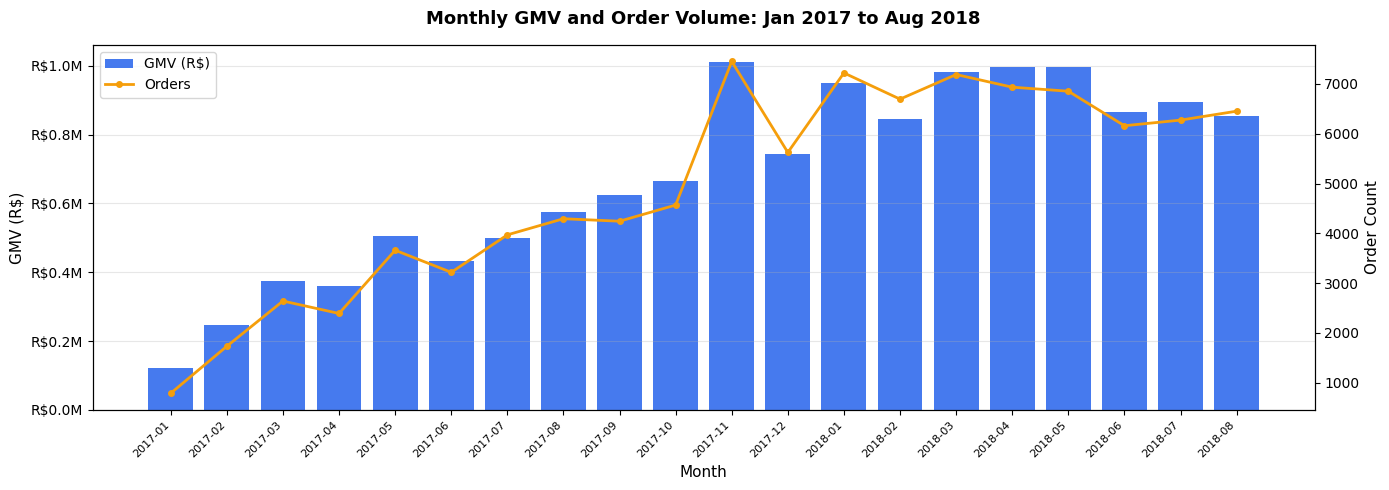

Saved: 01_Monthly_Revenue_Trend.png


In [15]:
# CHART: Monthly Revenue Trend ──────────────────────────────

fig, ax1 = plt.subplots(figsize=(14, 5))

# Revenue bars
ax1.bar(
    monthly_trend["order_ym_str"],
    monthly_trend["revenue"],
    color="#2563EB",
    alpha=0.85,
    label="GMV (R$)"
)

# Order count line on secondary axis
ax2 = ax1.twinx()
ax2.plot(
    monthly_trend["order_ym_str"],
    monthly_trend["orders"],
    color="#F59E0B",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Orders"
)

# Formatting
ax1.set_xlabel("Month", fontsize=11)
ax1.set_ylabel("GMV (R$)", fontsize=11)
ax2.set_ylabel("Order Count", fontsize=11)
ax1.set_title("Monthly GMV and Order Volume: Jan 2017 to Aug 2018",
              fontsize=13, fontweight="bold", pad=15)

# Rotate x labels so they don't overlap
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=8)

# Format y axis as currency
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M")
)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)

ax1.grid(axis="y", alpha=0.3)
fig.tight_layout()

chart_path = os.path.join(REPORT_PATH, "01_Monthly_Revenue_Trend.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: 01_Monthly_Revenue_Trend.png")

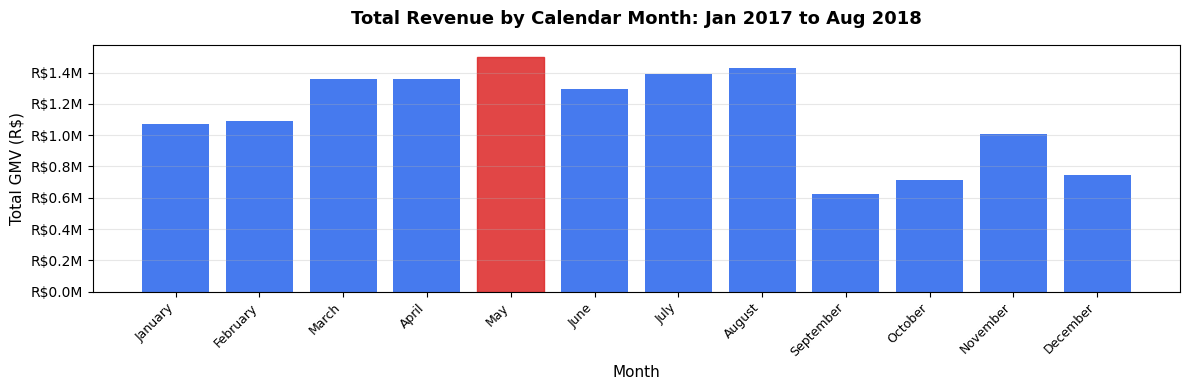

Peak month: May: R$ 1,502,588.82


In [16]:
# SEASONALITY: Average Revenue by Month of Year ────────────
#
# Averages GMV across both years for each calendar month.
# Reveals structural demand patterns independent of year-on-year growth.
# ──────────────────────────────────────────────────────────────

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

seasonality = (
    master.groupby("order_month")
    .agg(avg_revenue=("product_revenue", "sum"),
         order_count=("order_id",        "nunique"))
    .reindex(month_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 4))

bars = ax.bar(
    seasonality["order_month"],
    seasonality["avg_revenue"],
    color="#2563EB",
    alpha=0.85
)

# Highlight the peak month
peak_idx = seasonality["avg_revenue"].idxmax()
bars[peak_idx].set_color("#DC2626")

ax.set_title("Total Revenue by Calendar Month: Jan 2017 to Aug 2018",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Total GMV (R$)", fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M")
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

chart_path = os.path.join(REPORT_PATH, "02_Revenue_Seasonality.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()

peak_month = seasonality.loc[peak_idx, "order_month"]
peak_rev   = seasonality.loc[peak_idx, "avg_revenue"]
print(f"Peak month: {peak_month}: R$ {peak_rev:,.2f}")

## 3. Regional Analysis

Breaks down revenue and order volume by customer state and seller state.
Surfaces geographic concentration and identifies the supply-demand
distribution gap that drives freight cost and delivery performance.

In [17]:
# CUSTOMER STATE: REVENUE RANKING ───────────────────────────
#
# Aggregates revenue and order volume by customer state.
# Uses full master table (all 112,649 rows)
# is not affected by the ramp-up exclusion since it's a full-period
# total, not a month-over-month comparison.
# ──────────────────────────────────────────────────────────────

state_revenue = (
    master.groupby("state")
    .agg(
        revenue=("product_revenue", "sum"),
        orders=("order_id", "nunique"),
        avg_order_value=("product_revenue", "mean"),
        customers=("customer_unique_id", "nunique")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

state_revenue["revenue_share"] = (state_revenue["revenue"] / state_revenue["revenue"].sum() * 100)
state_revenue["cumulative_share"] = state_revenue["revenue_share"].cumsum()

print("═" * 70)
print("REVENUE BY CUSTOMER STATE: Full Period")
print("═" * 70)
print(state_revenue.to_string(index=False, float_format="%.2f"))

# Concentration check
top3_share = state_revenue.head(3)["revenue_share"].sum()
top5_share = state_revenue.head(5)["revenue_share"].sum()
print(f"\nTop 3 states share of total revenue: {top3_share:.1f}%")
print(f"Top 5 states share of total revenue: {top5_share:.1f}%")
print(f"Total states represented: {len(state_revenue)}")

══════════════════════════════════════════════════════════════════════
REVENUE BY CUSTOMER STATE: Full Period
══════════════════════════════════════════════════════════════════════
state    revenue  orders  avg_order_value  customers  revenue_share  cumulative_share
   SP 5202810.05   41374           109.65      39981          38.28             38.28
   RJ 1824092.67   12762           125.12      12303          13.42             51.70
   MG 1585308.03   11544           120.75      11178          11.66             63.36
   RS  750304.02    5432           120.34       5249           5.52             68.89
   PR  683083.76    4998           119.00       4840           5.03             73.91
   SC  520553.34    3612           124.65       3513           3.83             77.74
   BA  511349.99    3358           134.60       3257           3.76             81.50
   DF  302603.94    2125           125.77       2062           2.23             83.73
   GO  294591.95    2007           126.27    

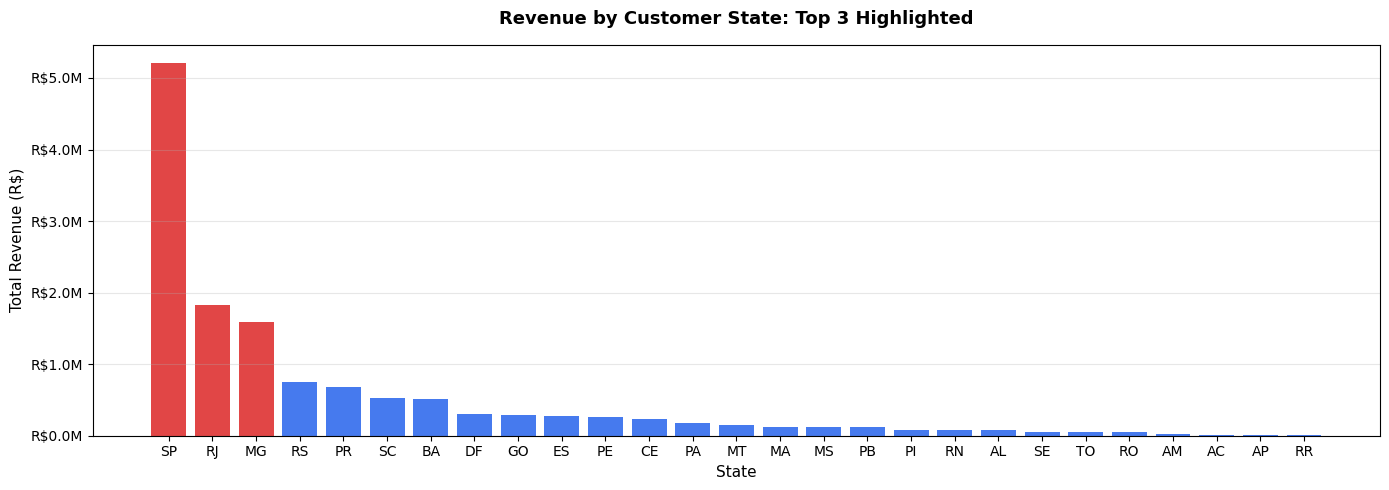

Saved: 03_Revenue_By_State.png


In [19]:
# CHART: Revenue by Customer State ──────────────────────────

fig, ax = plt.subplots(figsize=(14, 5))

colors = ["#DC2626" if i < 3 else "#2563EB" for i in range(len(state_revenue))]

bars = ax.bar(
    state_revenue["state"],
    state_revenue["revenue"],
    color=colors,
    alpha=0.85
)

ax.set_title("Revenue by Customer State: Top 3 Highlighted",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("State", fontsize=11)
ax.set_ylabel("Total Revenue (R$)", fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M")
)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

chart_path = os.path.join(REPORT_PATH, "03_Revenue_By_State.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 03_Revenue_By_State.png")

In [23]:
# SUPPLY-DEMAND GEOGRAPHIC GAP ────────────────────────────────
#
# Compares seller concentration vs customer concentration by state.
# A large gap indicates sellers are geographically concentrated
# while demand is national driving up freight cost and delivery
# time for customers far from seller hubs.
# ──────────────────────────────────────────────────────────────

seller_revenue = (
    master.groupby("seller_state")
    .agg(
        seller_revenue=("product_revenue", "sum"),
        sellers=("seller_id", "nunique"),
        avg_freight=("freight_value", "mean")
    )
    .reset_index()
    .rename(columns={"seller_state": "state"})
    .sort_values("seller_revenue", ascending=False)
)

seller_revenue["seller_revenue_share"] = (
    seller_revenue["seller_revenue"] / seller_revenue["seller_revenue"].sum() * 100
)

# Merge customer and seller views for direct comparison
supply_demand = state_revenue[["state", "revenue", "revenue_share"]].merge(
    seller_revenue[["state", "seller_revenue", "seller_revenue_share", "sellers", "avg_freight"]],
    on="state",
    how="outer"
).fillna(0)

supply_demand = supply_demand.rename(columns={
    "revenue": "customer_revenue",
    "revenue_share": "customer_revenue_share"
}).sort_values("customer_revenue", ascending=False)

print("═" * 110)
print("SUPPLY (SELLER) vs DEMAND (CUSTOMER): BY STATE")
print("═" * 110)
print(supply_demand.head(10).to_string(index=False, float_format="%.2f"))

top3_seller_share = seller_revenue.head(3)["seller_revenue_share"].sum()
print(f"\nTop 3 seller states share of total seller revenue: {top3_seller_share:.1f}%")
print(f"Total seller states represented: {len(seller_revenue)}")

══════════════════════════════════════════════════════════════════════════════════════════════════════════════
SUPPLY (SELLER) vs DEMAND (CUSTOMER): BY STATE
══════════════════════════════════════════════════════════════════════════════════════════════════════════════
state  customer_revenue  customer_revenue_share  seller_revenue  seller_revenue_share  sellers  avg_freight
   SP        5202810.05                   38.28      8753251.21                 64.40  1849.00        18.45
   RJ        1824092.67                   13.42       843984.22                  6.21   171.00        19.47
   MG        1585308.03                   11.66      1011564.74                  7.44   244.00        24.08
   RS         750304.02                    5.52       378559.54                  2.79   129.00        26.03
   PR         683083.76                    5.03      1261887.21                  9.28   349.00        22.72
   SC         520553.34                    3.83       632426.07                  4.

In [25]:
# AVERAGE FREIGHT COST BY CUSTOMER STATE ────────────────────
#
# Tests the hypothesis that customers far from seller concentration
# pay higher freight costs; a direct operational cost signal.
# ──────────────────────────────────────────────────────────────

freight_by_state = (
    master.groupby("state")
    .agg(
        avg_freight=("freight_value", "mean"),
        avg_price=("price", "mean"),
        orders=("order_id", "nunique")
    )
    .reset_index()
    .sort_values("avg_freight", ascending=False)
)

freight_by_state["freight_pct_of_price"] = (
    freight_by_state["avg_freight"] / freight_by_state["avg_price"] * 100
)

print("═" * 60)
print("AVERAGE FREIGHT COST BY CUSTOMER STATE: Highest to Lowest")
print("═" * 60)
print(freight_by_state.to_string(index=False, float_format="%.2f"))

════════════════════════════════════════════════════════════
AVERAGE FREIGHT COST BY CUSTOMER STATE: Highest to Lowest
════════════════════════════════════════════════════════════
state  avg_freight  avg_price  orders  freight_pct_of_price
   RR        42.98     150.57      46                 28.55
   PB        42.72     191.48     532                 22.31
   RO        41.07     165.97     247                 24.74
   AC        40.07     173.73      81                 23.07
   PI        39.15     160.36     493                 24.41
   MA        38.26     145.20     740                 26.35
   TO        37.25     157.53     279                 23.64
   SE        36.65     153.04     345                 23.95
   AL        35.84     180.89     411                 19.82
   PA        35.83     165.69     970                 21.63
   RN        35.65     156.97     482                 22.71
   AP        34.01     164.32      68                 20.69
   AM        33.21     135.50     147   

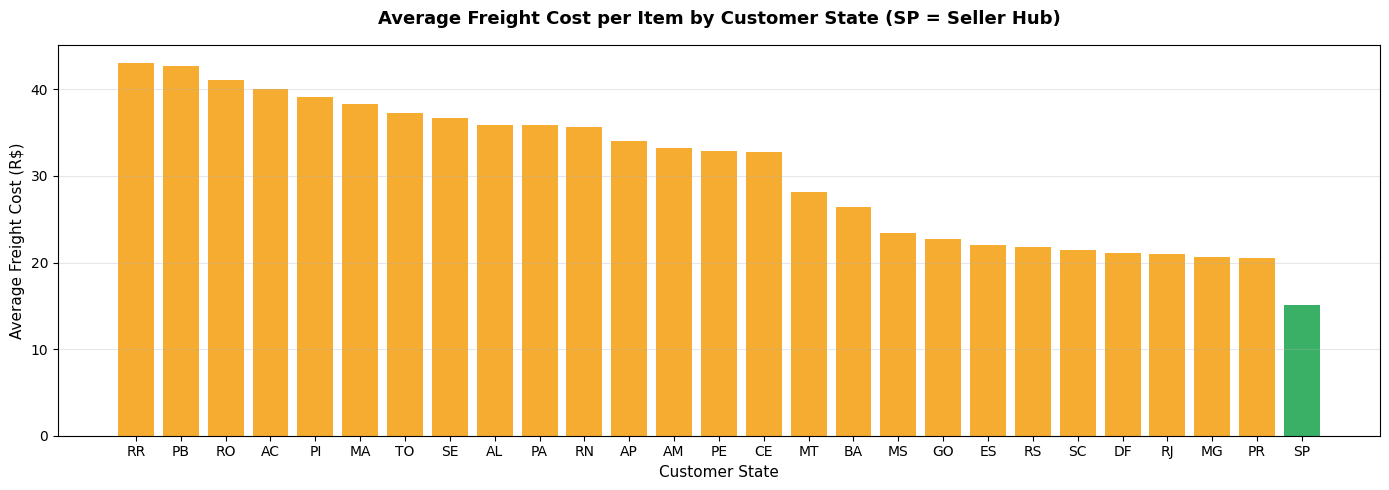

Saved: 04_Freight_By_State.png


In [26]:
# CHART: Average Freight Cost by State ──────────────────────

fig, ax = plt.subplots(figsize=(14, 5))

# Highlight SP (the dominant seller hub) for visual reference
colors = ["#16A34A" if s == "SP" else "#F59E0B" for s in freight_by_state["state"]]

ax.bar(
    freight_by_state["state"],
    freight_by_state["avg_freight"],
    color=colors,
    alpha=0.85
)

ax.set_title("Average Freight Cost per Item by Customer State (SP = Seller Hub)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Customer State", fontsize=11)
ax.set_ylabel("Average Freight Cost (R$)", fontsize=11)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

chart_path = os.path.join(REPORT_PATH, "04_Freight_By_State.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 04_Freight_By_State.png")

In [27]:
# STATES WITH NO REGISTERED SELLERS ─────────────────────────
#
# Confirms exactly which states have zero seller presence —
# strengthens the supply concentration finding with a hard count.
# ──────────────────────────────────────────────────────────────

all_customer_states = set(state_revenue["state"])
all_seller_states    = set(seller_revenue["state"])

no_seller_states = all_customer_states - all_seller_states

print(f"States with customer demand but ZERO registered sellers: {len(no_seller_states)}")
print(sorted(no_seller_states))

# Revenue these states generate despite having no local sellers
no_seller_revenue = state_revenue[state_revenue["state"].isin(no_seller_states)]
print(f"\nRevenue from these states (fully dependent on out-of-state sellers):")
print(no_seller_revenue[["state", "revenue", "orders"]].to_string(index=False, float_format="%.2f"))
print(f"\nCombined revenue: R$ {no_seller_revenue['revenue'].sum():,.2f}")

States with customer demand but ZERO registered sellers: 4
['AL', 'AP', 'RR', 'TO']

Revenue from these states (fully dependent on out-of-state sellers):
state  revenue  orders
   AL 80314.81     411
   TO 49621.74     279
   AP 13474.30      68
   RR  7829.43      46

Combined revenue: R$ 151,240.28


## 4. Category Analysis

Ranks product categories by revenue contribution, order volume, and
average item value. The "Unknown" category, products with no
category metadata is excluded from rankings and quantified separately.

In [28]:
# CONFIRM UNKNOWN CATEGORY SCOPE ────────────────────────────
#
# Quantifies the "Unknown" category before excluding it from
# rankings.
# ──────────────────────────────────────────────────────────────

unknown_mask = master["category_english"] == "Unknown"

unknown_revenue = master.loc[unknown_mask, "product_revenue"].sum()
unknown_orders  = master.loc[unknown_mask, "order_id"].nunique()
unknown_items   = unknown_mask.sum()

print("═" * 55)
print("UNKNOWN CATEGORY : Scope Confirmation")
print("═" * 55)
print(f"  Items with no category metadata: {unknown_items:,}")
print(f"  Orders affected:                  {unknown_orders:,}")
print(f"  Revenue:                          R$ {unknown_revenue:,.2f}")
print(f"  % of total revenue:               {unknown_revenue / total_revenue * 100:.2f}%")

═══════════════════════════════════════════════════════
UNKNOWN CATEGORY : Scope Confirmation
═══════════════════════════════════════════════════════
  Items with no category metadata: 1,627
  Orders affected:                  1,473
  Revenue:                          R$ 185,049.76
  % of total revenue:               1.36%


In [33]:
# CATEGORY REVENUE RANKING: Excludes Unknown ───────────────

category_perf = (
    master[master["category_english"] != "Unknown"]
    .groupby("category_english")
    .agg(
        revenue=("product_revenue", "sum"),
        orders=("order_id", "nunique"),
        items=("order_item_id", "count"),
        avg_item_value=("product_revenue", "mean"),
        avg_review_score=("review_score", "mean")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

category_perf["revenue_share"] = (
    category_perf["revenue"] / category_perf["revenue"].sum() * 100
)
category_perf["cumulative_share"] = category_perf["revenue_share"].cumsum()

print("═" * 115)
print("TOP 15 CATEGORIES BY REVENUE")
print("═" * 115)
print(category_perf.head(15).to_string(index=False, float_format="%.2f"))

top10_share = category_perf.head(10)["revenue_share"].sum()
print(f"\nTop 10 categories share of total (excl. Unknown): {top10_share:.1f}%")
print(f"Total categories: {len(category_perf)}")

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
TOP 15 CATEGORIES BY REVENUE
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
     category_english    revenue  orders  items  avg_item_value  avg_review_score  revenue_share  cumulative_share
        Health Beauty 1258681.34    8836   9670          130.16              4.14           9.39              9.39
        Watches Gifts 1205005.68    5624   5991          201.14              4.02           8.99             18.38
       Bed Bath Table 1036988.68    9417  11115           93.30              3.90           7.73             26.11
       Sports Leisure  988048.97    7720   8641          114.34              4.11           7.37             33.48
Computers Accessories  911954.32    6689   7827          116.51              3.93           6.80             40.28
      Furniture Decor  729762.49    6449   8334  

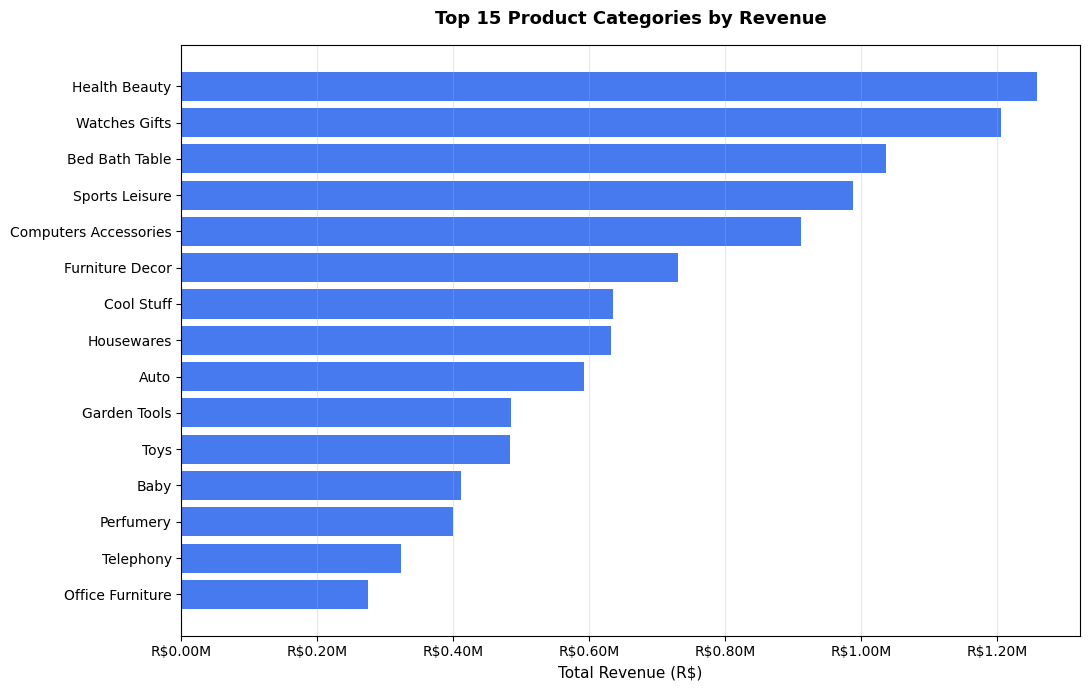

Saved: 05_Top_Categories_Revenue.png


In [34]:
# CHART: Top 15 Categories by Revenue ───────────────────────

top15 = category_perf.head(15).sort_values("revenue")

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(top15["category_english"], top15["revenue"], color="#2563EB", alpha=0.85)

ax.set_title("Top 15 Product Categories by Revenue", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Total Revenue (R$)", fontsize=11)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.2f}M")
)
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()

chart_path = os.path.join(REPORT_PATH, "05_Top_Categories_Revenue.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 05_Top_Categories_Revenue.png")

In [36]:
# PREMIUM vs VOLUME CATEGORY IDENTIFICATION ─────────────────
#
# Identifies categories that are high-value-per-item (premium)
# vs high-volume-low-value (volume play). Filtered to categories
# with at least 100 orders to avoid noise from tiny categories.
# ──────────────────────────────────────────────────────────────

meaningful_categories = category_perf[category_perf["orders"] >= 100].copy()

print("═" * 65)
print("TOP 10 HIGHEST AVERAGE ITEM VALUE (min. 100 orders)")
print("═" * 65)
print(meaningful_categories.sort_values("avg_item_value", ascending=False)
      .head(10)[["category_english", "avg_item_value", "orders", "revenue"]]
      .to_string(index=False, float_format="%.2f"))

print("\n" + "═" * 65)
print("TOP 10 HIGHEST ORDER VOLUME (min. 100 orders)")
print("═" * 65)
print(meaningful_categories.sort_values("orders", ascending=False)
      .head(10)[["category_english", "orders", "avg_item_value", "revenue"]]
      .to_string(index=False, float_format="%.2f"))

═════════════════════════════════════════════════════════════════
TOP 10 HIGHEST AVERAGE ITEM VALUE (min. 100 orders)
═════════════════════════════════════════════════════════════════
          category_english  avg_item_value  orders    revenue
                 Computers         1098.34     181  222963.13
         Home Appliances 2          476.12     234  113317.74
Agro Industry And Commerce          342.12     182   72530.47
       Musical Instruments          281.62     628  191498.88
          Small Appliances          280.78     630  190648.58
           Fixed Telephony          225.69     217   59583.00
 Construction Tools Safety          208.99     167   40544.52
             Watches Gifts          201.14    5624 1205005.68
          Air Conditioning          185.27     253   55024.96
                Cool Stuff          167.36    3632  635290.85

═════════════════════════════════════════════════════════════════
TOP 10 HIGHEST ORDER VOLUME (min. 100 orders)
═════════════════════

In [ ]:
# LOWEST-RATED CATEGORIES (min. 100 orders) ─────────────────
#
# Flags categories with the lowest average review scores
# a direct signal for the operational recommendation memo.
# ──────────────────────────────────────────────────────────────

print("═" * 70)
print("BOTTOM 10 CATEGORIES BY AVERAGE REVIEW SCORE (min. 100 orders)")
print("═" * 70)
print(meaningful_categories.sort_values("avg_review_score")
      .head(10)[["category_english", "avg_review_score", "orders", "revenue"]]
      .to_string(index=False, float_format="%.2f"))

══════════════════════════════════════════════════════════════════════
BOTTOM 10 CATEGORIES BY AVERAGE REVIEW SCORE (min. 100 orders)
══════════════════════════════════════════════════════════════════════
         category_english  avg_review_score  orders    revenue
         Office Furniture              3.49    1273  273960.70
    Fashion Male Clothing              3.64     112   10797.82
          Fixed Telephony              3.68     217   59583.00
             Home Confort              3.83     397   58572.04
                    Audio              3.83     350   50688.50
Construction Tools Safety              3.84     167   40544.52
           Bed Bath Table              3.90    9417 1036988.68
    Furniture Living Room              3.90     422   68916.56
          Furniture Decor              3.91    6449  729762.49
    Computers Accessories              3.93    6689  911954.32


In [38]:
# REVIEW SCORE vs PRICE POINT: Pattern Check ───────────────
#
# Tests whether dissatisfaction correlates with item price point
# generally, or whether it's isolated to specific categories
# (e.g. Office Furniture) regardless of price.
# ──────────────────────────────────────────────────────────────

correlation = meaningful_categories[["avg_item_value", "avg_review_score"]].corr().iloc[0, 1]

print(f"Correlation between avg item value and avg review score: {correlation:.3f}")
print(f"\nInterpretation: ", end="")
if abs(correlation) < 0.2:
    print("No meaningful relationship. Dissatisfaction is category-specific, not price-driven.")
elif correlation > 0:
    print("Weak positive. Pricier items tend to rate slightly higher.")
else:
    print("Weak negative. Pricier items tend to rate slightly lower.")

Correlation between avg item value and avg review score: 0.039

Interpretation: No meaningful relationship. Dissatisfaction is category-specific, not price-driven.
